In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import sklearn

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
from nltk.corpus import wordnet

In [3]:
#nltk.download("wordnet")
#nltk.download("omw-1.4")
#nltk.download("punkt")

In [4]:
all_data = pd.read_csv("data/Reviews.csv",engine="python")

In [5]:
all_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
df = all_data[["Score", "Text"]].copy()

In [7]:
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [8]:
df.isna().sum()

Score    0
Text     0
dtype: int64

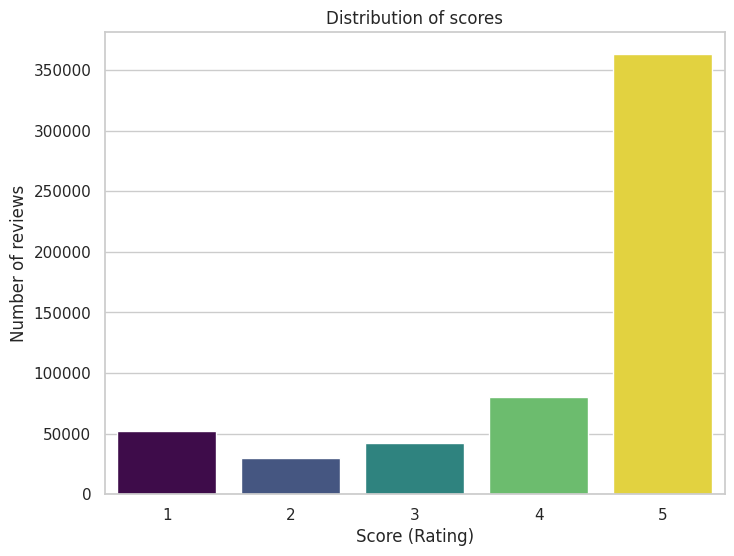

In [9]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(x="Score", data=df, hue="Score", palette="viridis", legend=False)

plt.title("Distribution of scores")
plt.xlabel("Score (Rating)")
plt.ylabel("Number of reviews")
plt.show()

In [10]:
test_df = df.sample(n=7500, random_state=42)
remaining_df = df.drop(test_df.index)

In [11]:
val_df = remaining_df.sample(n=7500, random_state=42)
train_pool = remaining_df.drop(val_df.index)

In [12]:
samples_per_class = 7000

In [13]:
balanced_dfs = []
for score_val, group in train_pool.groupby("Score"):
  sampled_group = group.sample(n=samples_per_class, random_state=42)
  balanced_dfs.append(sampled_group)

In [14]:
train_balanced = pd.concat(balanced_dfs).reset_index(drop=True)

In [15]:
lemmatizer = WordNetLemmatizer()

In [16]:
def get_wordnet_pos(word):
  tag = nltk.pos_tag([word])[0][1].upper()
  if tag.startswith("J") or tag.startswith("S"):
    return wordnet.ADJ
  elif tag.startswith("V"):
    return wordnet.VERB
  elif tag.startswith("N"):
    return wordnet.NOUN
  elif tag.startswith("R"):
    return wordnet.ADV
  else:
    return wordnet.NOUN  

In [17]:
def lemmatize_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()

    lemmatized_words = [lemmatizer.lemmatize(word, pos=get_wordnet_pos(word)) for word in words]
    return " ".join(lemmatized_words)    

In [18]:
train_balanced["Cleaned_Text"] = train_balanced["Text"].apply(lemmatize_text)
val_df["Cleaned_Text"] = val_df["Text"].apply(lemmatize_text)
test_df["Cleaned_Text"] = test_df["Text"].apply(lemmatize_text)

In [19]:
#test_df

In [20]:
train_balanced.to_csv("data/train_df.csv", index=False)
val_df.to_csv("data/validation_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)

In [21]:
custom_stop_words = list(sklearn.feature_extraction.text.ENGLISH_STOP_WORDS - {"not", "no", "never", "nor","but"})

In [22]:
vectorizer = TfidfVectorizer(max_features=10000,stop_words=custom_stop_words, ngram_range=(1,2), lowercase=True)

In [23]:
X_train_vec = vectorizer.fit_transform(train_balanced["Cleaned_Text"])
y_train = train_balanced["Score"]

In [24]:
X_val_vec = vectorizer.transform(val_df["Cleaned_Text"])
y_val = val_df["Score"]

In [25]:
X_test_vec = vectorizer.transform(test_df["Cleaned_Text"])
y_test = test_df["Score"]

In [26]:
with open("prepared_data.pkl", "wb") as f:
  pickle.dump((X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test, vectorizer),f)